In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

In [24]:
data = pd.read_csv('healthcare_dataset1.csv')
data.head()


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [25]:
data.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [26]:
data.duplicated().sum()


np.int64(534)

In [27]:
data.drop_duplicates(inplace=True)

In [28]:
data.duplicated().sum()
data.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [29]:
data= data.drop(columns= ['Name', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number'])
data.head()

,Age,Gender,Blood Type,Medical Condition,Date of Admission,Admission Type,Discharge Date,Medication,Test Results
0,30,Male,B-,Cancer,2024-01-31,Urgent,2024-02-02,Paracetamol,Normal
1,62,Male,A+,Obesity,2019-08-20,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,76,Female,A-,Obesity,2022-09-22,Emergency,2022-10-07,Aspirin,Normal
3,28,Female,O+,Diabetes,2020-11-18,Elective,2020-12-18,Ibuprofen,Abnormal
4,43,Female,AB+,Cancer,2022-09-19,Urgent,2022-10-09,Penicillin,Abnormal


In [30]:
import matplotlib.pyplot as plt

<Axes: xlabel='Gender'>

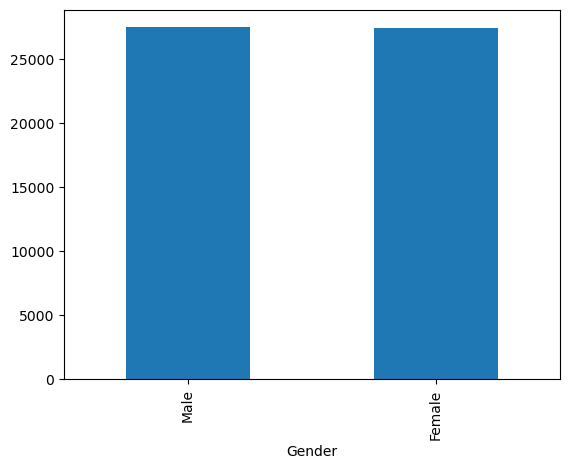

In [31]:
data["Gender"].value_counts().plot(kind="bar")

<Axes: xlabel='Test Results'>

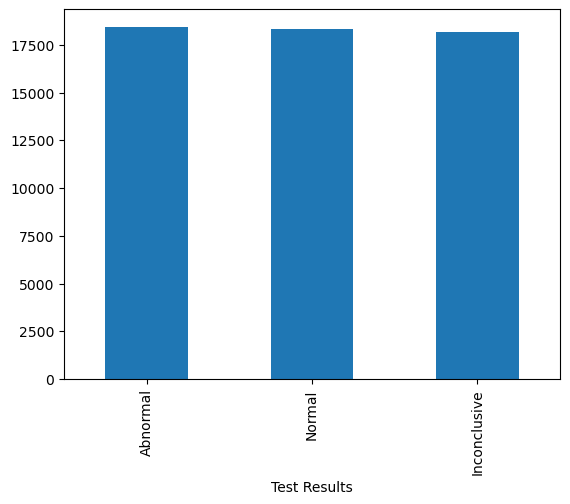

In [32]:
data["Test Results"].value_counts().plot(kind="bar")

In [33]:
x= data.drop(columns=['Test Results'])
x.head()


,Age,Gender,Blood Type,Medical Condition,Date of Admission,Admission Type,Discharge Date,Medication
0,30,Male,B-,Cancer,2024-01-31,Urgent,2024-02-02,Paracetamol
1,62,Male,A+,Obesity,2019-08-20,Emergency,2019-08-26,Ibuprofen
2,76,Female,A-,Obesity,2022-09-22,Emergency,2022-10-07,Aspirin
3,28,Female,O+,Diabetes,2020-11-18,Elective,2020-12-18,Ibuprofen
4,43,Female,AB+,Cancer,2022-09-19,Urgent,2022-10-09,Penicillin


In [34]:
y=data["Test Results"]

In [35]:
y.head()

0          Normal
1    Inconclusive
2          Normal
3        Abnormal
4        Abnormal
Name: Test Results, dtype: object

In [36]:
x_train, x_test, y_train, y_test = train_test_split (x, y, test_size=0.2)
print("x_train shape: {}".format(x_train.shape)) 
print("x_test shape: {}".format(x_test.shape))

print("y_train shape: {}".format(y_train.shape))
print("y_test shape: {}".format(y_test.shape))

x_train shape: (43972, 8)
x_test shape: (10994, 8)
y_train shape: (43972,)
y_test shape: (10994,)


In [37]:
categorical_columns = [
    "Gender", "Blood Type", "Medical Condition",
    "Date of Admission", "Admission Type", "Medication"]

numerical_columns = ["Age"]

# Transformer
categorical_Transformer = OneHotEncoder(handle_unknown='ignore')
numerical_Transformer = StandardScaler()

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_Transformer, numerical_columns),
    ("cat", categorical_Transformer, categorical_columns)
])

In [38]:
knn= KNeighborsClassifier(n_neighbors=1)

In [39]:
knn.fit(preprocessor.fit_transform(x_train), y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [40]:
knn_predictions = knn.predict(preprocessor.transform(x_test))

In [42]:
evaluation_results= accuracy_score(y_test, knn_predictions)
print("accuracy:")
print(evaluation_results)

accuracy:
0.4214116790976897
